In [1]:
import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

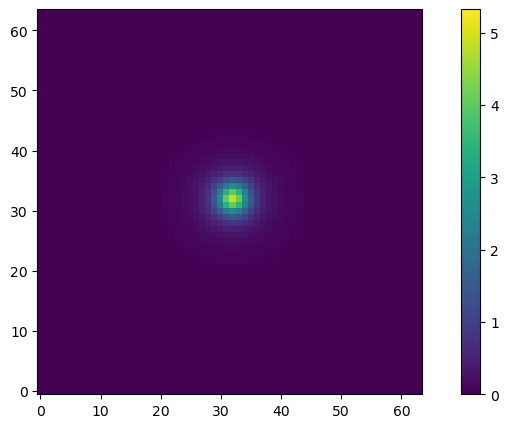

In [2]:
npix = 64
pixel_scale = 0.2  # LSST image pixel scale
# noise variance for r-bands 10 year LSST coadd (magnitude zero point at 30)
noise_std = 0.37
noise_variance = noise_std**2.0
noise_array = None
seed = 2

lens_shear = 0.04

psf_obj = galsim.Moffat(beta=3.5, fwhm=0.6, trunc=0.6 * 4.0)
psf_array = (
    psf_obj.shift(0.5 * pixel_scale, 0.5 * pixel_scale)
    .drawImage(nx=npix, ny=npix, scale=pixel_scale)
    .array
)

hlr = 0.6
gal = galsim.Sersic(n=4, half_light_radius=hlr, flux=200)
gal = gal.shift(0.5*pixel_scale, 0.5*pixel_scale)
gal_shear = gal.shear(g1=lens_shear, g2=0.0)
gal_conv = galsim.Convolve([gal_shear, psf_obj])

gal_img = gal_conv.drawImage(nx=npix, ny=npix, scale=pixel_scale)
gal_array = gal_img.array
plt.figure(figsize=(10, 5))
plt.imshow(gal_array, origin="lower", vmin=0, vmax=gal_array.max() * 1.1)
plt.colorbar()

In [3]:
# Force detections at the centers
indx = np.arange(npix // 2, npix, npix)
indy = np.arange(npix // 2, npix, npix)
ns = len(indx) * len(indy)
inds = np.meshgrid(indy, indx, indexing="ij")
yx = np.vstack([np.ravel(_) for _ in inds])
dtype = np.dtype(
    [
        ("y", np.int32),
        ("x", np.int32),
    ]
)
detection = np.empty(ns, dtype=dtype)
detection["y"] = yx[0]
detection["x"] = yx[1]

def measure_shear(gal_array, psf_array, pixel_scale, noise_variance, noise_array, detection, shear_true):
    fpfs_config = anacal.fpfs.FpfsConfig(
        sigma_shapelets=0.52,  # The first measurement scale (also for detection)
        sigma_shapelets2=0.45,  # The second measurement scale
    )
    catalog = anacal.fpfs.process_image(
        fpfs_config=fpfs_config,
        mag_zero=30.0,
        gal_array=gal_array,
        psf_array=psf_array,
        pixel_scale=pixel_scale,
        noise_variance=max(noise_variance, 0.23),
        noise_array=noise_array,
        detection=detection,
    )

    e1 = catalog["fpfs_w"] * catalog["fpfs_e1"]
    e1g1 = (
        catalog["fpfs_dw_dg1"] * catalog["fpfs_e1"]
        + catalog["fpfs_w"] * catalog["fpfs_de1_dg1"]
    )

    mbias = np.sum(e1) / np.sum(e1g1) / shear_true - 1  # 0.04 is the input shear

    return np.sum(e1) / np.sum(e1g1), mbias

g1, mbias = measure_shear(gal_array, psf_array, pixel_scale, noise_variance, noise_array, detection, shear_true=0.04)
print(f"g1: {g1:.4f}, multiplicative bias: {mbias:.4f}")

g1: 0.0400, multiplicative bias: 0.0011


In [5]:
# Create IA transform
IATransform = batsim.IaTransform(
    scale=pixel_scale,
    hlr=hlr,
    A=0.00136207,
    beta=0.82404653, # best first Georgiou19+
    phi = np.radians(0),
    clip_radius=5 # clip the transform at 5*hlr to prevent edge effects
)

LensTransform = batsim.LensTransform(gamma1=lens_shear, gamma2=0.0, kappa=0)

TransformList = [IATransform, LensTransform]

gal_ia = batsim.simulate_galaxy(
    ngrid=npix,
    pix_scale=pixel_scale,
    gal_obj=gal.shift(-0.5*pixel_scale, -0.5*pixel_scale),  # shift back to the center for the IA transform
    transform_obj=TransformList,
    psf_obj=psf_obj,
    draw_method="auto"
)

g1, mbias = measure_shear(gal_ia, psf_array, pixel_scale, noise_variance, noise_array, detection, shear_true=0.04)
print(f"g1: {g1:.4f}, multiplicative bias: {mbias:.4f}")

g1: 0.0408, multiplicative bias: 0.0207


# Simulate sample of ~ 1000 galaxies
- Measure multiplicative bias including PSF, and noise
- Apply IA shear to ~ 10% of galaxies and observe how multiplicative bias changes

100%|██████████| 1000/1000 [01:05<00:00, 15.36it/s]


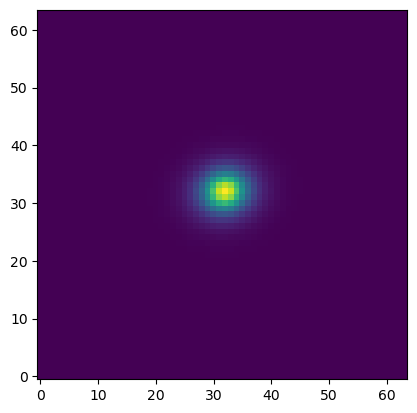

In [ ]:
np.random.seed(14)

ngals = 1000
ia_frac = 0.05
npix = 64
pixel_scale = 0.2  # LSST image pixel scale
noise_std = 0.37
noise_variance = noise_std**2.0
sigma_e = 0.26 # shape noise

noise_array = None

lens_shear = 0.04

# Work out correct image size to include all stamps
scene = galsim.ImageF(npix * ngals, npix, scale=pixel_scale)

psf = galsim.Moffat(beta=3.5, fwhm=0.6, trunc=0.6 * 4.0)
psf_array = psf.shift(0.5 * pixel_scale, 0.5 * pixel_scale).drawImage(nx=npix, ny=npix, scale=pixel_scale).array

for i in trange(ngals):
    hlr = np.random.uniform(0.1, 1.0)

    while True: # Ensure we get a valid shape with |e| < 1
        e1 = np.random.normal(0, sigma_e)
        e2 = np.random.normal(0, sigma_e)
        if np.hypot(e1, e2) < 1:
            break

    # Just use Sersic galaxies for now
    gal = galsim.Sersic(
        n=np.random.uniform(1.0, 4.0),
        half_light_radius=hlr,
        flux=np.random.uniform(200, 1000)
    ).shear(e1=e1, e2=e2)

    # if galaxy is an IA galaxy, apply the IA transform
    if np.random.rand() < ia_frac:
        IATransform = batsim.IaTransform(
            scale=pixel_scale,
            hlr=hlr,
            A=0.00136207,
            beta=0.82404653, # best fit Georgiou19+
            phi = np.radians(0),
            clip_radius=5 # clip the transform at 5*hlr to prevent edge effects
        )
        gal_array = batsim.simulate_galaxy(
            ngrid=npix,
            pix_scale=pixel_scale,
            gal_obj=gal,  # shift back to the center for the IA transform
            transform_obj=IATransform,
            psf_obj=psf,
            draw_method="no_pixel"
        )
        
        # Apply lensing trasnform through BATSim
        LensTransform = batsim.LensTransform(gamma1=lens_shear, gamma2=0.0)

    else:
        gal = gal.shift(0.5*pixel_scale, 0.5*pixel_scale) # shift the galaxy to center

        # lens galaxy after applying IA transform
        gal = gal.shear(g1=lens_shear, g2=0.0)

        # Convolve after both IA and lensing
        gal = galsim.Convolve([gal, psf])
        gal_array = gal.drawImage(nx=npix, ny=npix, scale=pixel_scale).array

    # Add noise
    # gal_array += np.random.normal(0, noise_std, size=gal_array.shape)

    # Comput the bounds for this galaxy
    xmin = int(i * npix) + 1
    xmax = int((i + 1) * npix)
    ymin = 1
    ymax = npix

    # Set the subimage in the stamp
    bounds = galsim.BoundsI(xmin, xmax, ymin, ymax)
    sub_image = galsim.Image(gal_array, scale=pixel_scale)
    scene[bounds] = sub_image

plt.imshow(scene.array[:64,:64], origin="lower")

In [20]:
# Force detections at the centers
indx = np.arange(npix // 2, npix * ngals, npix)
indy = np.arange(npix // 2, npix, npix)
ns = len(indx) * len(indy)
inds = np.meshgrid(indy, indx, indexing="ij")
yx = np.vstack([np.ravel(_) for _ in inds])
dtype = np.dtype(
    [
        ("y", np.int32),
        ("x", np.int32),
    ]
)
detection = np.empty(ns, dtype=dtype)
detection["y"] = yx[0]
detection["x"] = yx[1]

g1, mbias = measure_shear(scene.array, psf_array, pixel_scale, noise_variance, noise_array, detection, shear_true=lens_shear)
print(f"g1: {g1:.4f}, multiplicative bias: {mbias:.4f}")

g1: 0.0350, multiplicative bias: -0.1255


0% IA: g1 = 0.0341, multiplicative bias = -0.1483 \
10% IA: g1 = 0.0342, multiplicative bias = -0.1458 \
25% IA: g1 = 0.0343, multiplicative bias = -0.1424